<a href="https://colab.research.google.com/github/LinglinNero/MSSP607/blob/main/Assignment1_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
#connect to github file
from google.colab import userdata
import os

github_token = userdata.get('Git_Hub')
owner = 'LinglinNero' # Replace with the GitHub repository owner
repository = 'MSSP607' # Replace with the GitHub repository name

clone_url = f'https://{github_token}@github.com/{owner}/{repository}.git'

# Clone the repository
!git clone {clone_url}

fatal: destination path 'MSSP607' already exists and is not an empty directory.


In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.formula.api import ols
from matplotlib.patches import Patch


In [14]:
df = pd.read_csv('/content/drive/MyDrive/MSSP607/Assignments/Assignment1/data_academic_performance 2.csv')

##Data preview
df.info()
#missing value
missing = df.isnull().sum()
print(missing)
#category
categorical_cols = df.select_dtypes(include=["object", "category"]).columns
print(list(categorical_cols))

for col in categorical_cols:
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts(dropna=False))



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12411 entries, 0 to 12410
Data columns (total 45 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   COD_S11           12411 non-null  object 
 1   GENDER            12411 non-null  object 
 2   EDU_FATHER        12411 non-null  object 
 3   EDU_MOTHER        12411 non-null  object 
 4   OCC_FATHER        12411 non-null  object 
 5   OCC_MOTHER        12411 non-null  object 
 6   STRATUM           12411 non-null  object 
 7   SISBEN            12411 non-null  object 
 8   PEOPLE_HOUSE      12411 non-null  object 
 9   Unnamed: 9        0 non-null      float64
 10  INTERNET          12411 non-null  object 
 11  TV                12411 non-null  object 
 12  COMPUTER          12411 non-null  object 
 13  WASHING_MCH       12411 non-null  object 
 14  MIC_OVEN          12411 non-null  object 
 15  CAR               12411 non-null  object 
 16  DVD               12411 non-null  object

In [15]:
##Data clean
df = df.drop(columns = ['Unnamed: 9'], errors = 'ignore')
#Missing value
cols_with_na = [
    'EDU_FATHER', 'EDU_MOTHER', 'OCC_FATHER', 'OCC_MOTHER',
    'STRATUM', 'SISBEN', 'REVENUE', 'JOB','PEOPLE_HOUSE'
]
for col in cols_with_na:
    df[col] = df[col].replace('0', np.nan)
#house number
df['PEOPLE_HOUSE'] = df['PEOPLE_HOUSE'].str.strip().str.upper()
house_number_map = {
    "ONE": 1, "ONCE": 1,
    "TWO": 2, "THREE": 3, "FOUR": 4, "FIVE": 5,
    "SIX": 6, "SEVEN": 7, "EIGHT": 8,
    "NUEVE": 9, "NINE": 9,
    "TEN": 10, "ELEVEN": 11,
    "TWELVE": 12, "TWELVE OR MORE": 12
}
df['People_in_house'] = df['PEOPLE_HOUSE'].map(house_number_map)
df['People_in_house'] = df['People_in_house'].astype('Int64')

#gender
df['Gender_Label'] = df['GENDER'].map({0: 'Male', 1: 'Female'})

#stratum
df['Stratum'] = (df['STRATUM'].astype(str).str.extract(r'(\d+)')[0].astype(float).astype('Int64'))

#education
Edu_map = {
    "NINGUNO": 1,
    "INCOMPLETE PRIMARY": 2,
    "COMPLETE PRIMARY": 3,
    "INCOMPLETE SECUNDARY": 4,
    "COMPLETE SECUNDARY": 5,
    "INCOMPLETE TECHNICAL OR TECHNOLOGICAL": 6,
    "COMPLETE TECHNIQUE OR TECHNOLOGY": 7,
    "INCOMPLETE PROFESSIONAL EDUCATION": 8,
    "COMPLETE PROFESSIONAL EDUCATION": 9,
    "POSTGRADUATE EDUCATION": 10
}

for col in ['EDU_FATHER', 'EDU_MOTHER']:
    s = (
        df[col].astype(str).str.strip().str.upper()
        .replace({'NOT SURE': np.nan, '0': np.nan})
        .map(Edu_map)
    )
    df[col+'_NUM'] = s.astype('Int64')

#revenue
Rev_map = {
    "LESS THAN 1 LMMW": 1,
    "BETWEEN 1 AND LESS THAN 2 LMMW": 2,
    "BETWEEN 2 AND LESS THAN 3 LMMW": 3,
    "BETWEEN 3 AND LESS THAN 5 LMMW": 4,
    "BETWEEN 5 AND LESS THAN 7 LMMW": 5,
    "BETWEEN 7 AND LESS THAN 10 LMMW": 6,
    "10 OR MORE LMMW": 7
}
df['Revenue_amount'] = df['REVENUE'].astype(str).str.upper().map(Rev_map).astype('Int64')

In [16]:
#Confidence interval
d = df.copy().dropna(subset = ['G_SC'])
def mean_ci(series, conf = 0.95):
      s = series.dropna().astype(float)
      n = len(s)
      if n == 0:
          return np.nan, np.nan, np.nan
      m = s.mean()
      se = s.std(ddof = 1)/np.sqrt(n)
      h = se * stats.t.ppf((1 + conf) / 2, n - 1)
      return m, m-h, m+h

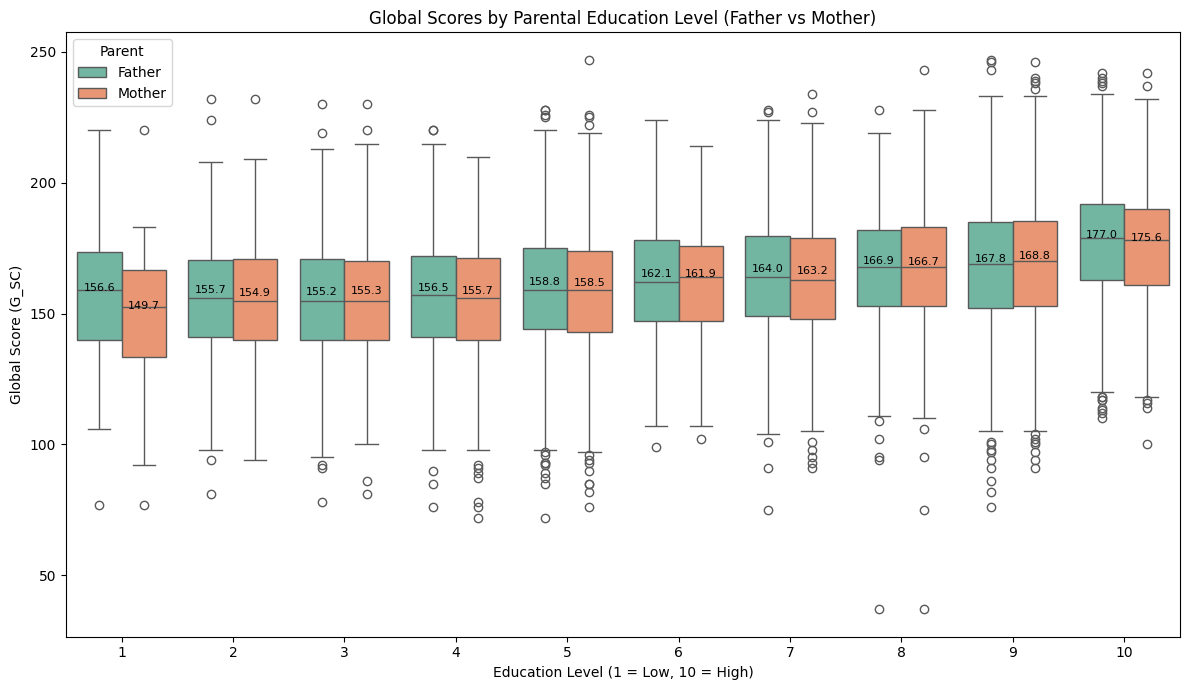

In [17]:
#Parents education to scores

df_melt = d.melt(
    id_vars="G_SC",
    value_vars=["EDU_FATHER_NUM", "EDU_MOTHER_NUM"],
    var_name="Parent_raw",
    value_name="Education_Level"
)

df_melt.dropna(subset=['Education_Level'], inplace=True)
df_melt['Education_Level'] = df_melt['Education_Level'].astype(int)

df_melt["Parent"] = df_melt["Parent_raw"].map({
    "EDU_FATHER_NUM": "Father",
    "EDU_MOTHER_NUM": "Mother"
})

plt.figure(figsize=(12, 7))
ax = sns.boxplot(
    data=df_melt,
    x="Education_Level",
    y="G_SC",
    hue="Parent",
    palette="Set2"
)

means = (
    df_melt.groupby(["Parent_raw", "Education_Level"])["G_SC"]
    .mean()
    .reset_index()
)

for _, row in means.iterrows():
    x = row["Education_Level"] - 1 + (0.2 if row["Parent_raw"] == "EDU_MOTHER_NUM" else -0.2)
    y = row["G_SC"]
    ax.text(
        x, y + 2, f"{y:.1f}", ha="center", color="black", fontsize=8
    )

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ["Father", "Mother"], title="Parent", loc="upper left")

plt.title("Global Scores by Parental Education Level (Father vs Mother)")
plt.ylabel("Global Score (G_SC)")
plt.xlabel("Education Level (1 = Low, 10 = High)")
plt.tight_layout()
plt.show()

/tmp/ipython-input-1622914287.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([str(x) for x in order])


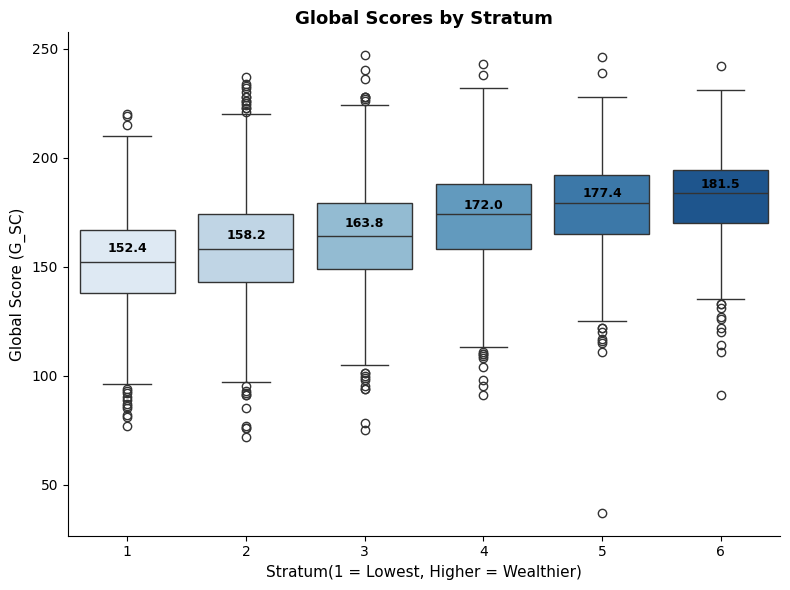


ANOVA: G_SC ~ C(Stratum)
                        sum_sq       df          F         PR(>F)
C(Stratum_order)  6.853163e+05      5.0  286.06371  1.425599e-290
Residual          5.936967e+06  12391.0        NaN            NaN

Tukey HSD pairwise comparisons:
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     1      2   5.8465    0.0  4.0455  7.6474   True
     1      3  11.4625    0.0  9.6626 13.2624   True
     1      4  19.6497    0.0 17.4716 21.8278   True
     1      5  25.0342    0.0 22.1314  27.937   True
     1      6  29.1583    0.0 25.7035 32.6131   True
     2      3    5.616    0.0  4.2274  7.0046   True
     2      4  13.8032    0.0 11.9505  15.656   True
     2      5  19.1877    0.0 16.5204 21.8551   True
     2      6  23.3119    0.0 20.0524 26.5713   True
     3      4   8.1872    0.0  6.3355 10.0389   True
     3      5  13.5717    0.0 10.9051 16.2384   True
 

In [18]:
##stratum
#boxplot
sub = df.copy()
sub['Stratum'] = pd.to_numeric(sub['Stratum'], errors = 'coerce')
sub = sub.dropna(subset = ['G_SC','Stratum'])

order = sorted(sub['Stratum'].astype(int).unique())
sub['Stratum_order'] = pd.Categorical(sub['Stratum'].astype(int),categories = order, ordered = True)

base = sns.color_palette('Blues',n_colors = len(order))
palette_map = {order[i]:base[i] for i in range(len(order))}

plt.figure(figsize = (8,6))
ax = sns.boxplot(
    data = sub,
    x = 'Stratum_order',
    y = 'G_SC',
    hue = 'Stratum_order',
    hue_order = order,
    dodge = False,
    palette = palette_map,
    legend = False
)

means = (sub.groupby("Stratum_order", observed=True)["G_SC"]
           .mean()
           .reindex(order))
for i, m in enumerate(means.values):
    ax.text(i, m + 3, f"{m:.1f}", ha="center", va="bottom",
            fontsize=9, color="black", fontweight="bold")

ax.set_title('Global Scores by Stratum', fontsize = 13, fontweight = 'bold')
ax.set_xlabel('Stratum(1 = Lowest, Higher = Wealthier)', fontsize = 11)
ax.set_ylabel('Global Score (G_SC)', fontsize = 11)
ax.set_xticklabels([str(x) for x in order])

sns.despine()
plt.tight_layout()
plt.show()

# significant test/ Tukey HSD
model = ols('G_SC ~ C(Stratum_order)', data=sub).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print('\nANOVA: G_SC ~ C(Stratum)')
print(anova_table)

tukey = pairwise_tukeyhsd(endog=sub['G_SC'], groups=sub['Stratum_order'], alpha=0.05)
print('\nTukey HSD pairwise comparisons:')
print(tukey)

        count    mean    std
GENDER                      
F        5043  161.28  22.33
M        7368  163.69  23.58


T-statistic = 5.777
P-value = 0.0000




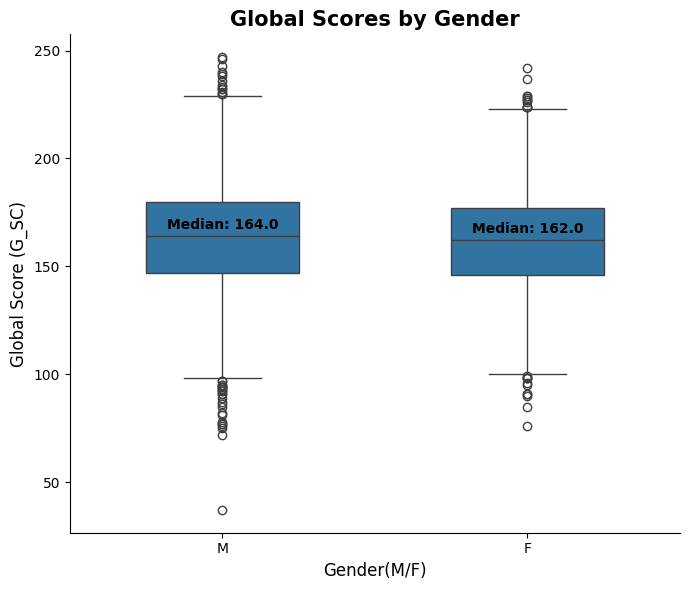

In [19]:
##Gender
medians = (
    df.groupby("GENDER", observed=True)["G_SC"]
    .median()
    .round(1)
)

# --- Corrected Plot code: Use data=df ---
plt.figure(figsize=(7, 6))
ax = sns.boxplot(
    data=df,
    x="GENDER",
    y="G_SC",
    order=['M', 'F'],
    dodge=False,
    legend=False,
    width=0.5
)

# Add median annotations (rest of your plotting code remains the same)
for tick, label in zip(range(len(medians)), ax.get_xticklabels()):
    gender = label.get_text()
    # Handle potential KeyError if a category is missing after filtering, although unlikely here
    if gender in medians:
        median_val = medians[gender]
        ax.text(
            tick,
            median_val + 2,
            f"Median: {median_val:.1f}",
            ha="center",
            va="bottom",
            fontsize=10,
            color="black",
            fontweight="bold"
        )

ax.set_title('Global Scores by Gender', fontsize=15, fontweight='bold')
ax.set_xlabel('Gender(M/F)', fontsize=12)
ax.set_ylabel('Global Score (G_SC)', fontsize=12)
sns.despine()
plt.tight_layout()
# Save the plot instead of showing it
plt.savefig('gender_boxplot.png') # Added savefig

# --- t-test code (remains the same, uses df) ---
gender_groups = df.groupby("GENDER")["G_SC"].agg(["count", "mean", "std"])
print(gender_groups.round(2))
print("\n" + "="*40 + "\n")
male_scores = df.loc[df["GENDER"] == 'M', "G_SC"].dropna()
female_scores = df.loc[df["GENDER"] == 'F', "G_SC"].dropna()
t_stat, p_val = stats.ttest_ind(male_scores, female_scores, equal_var=False)
print(f"T-statistic = {t_stat:.3f}")
print(f"P-value = {p_val:.4f}")
print("\n" + "="*40 + "\n")

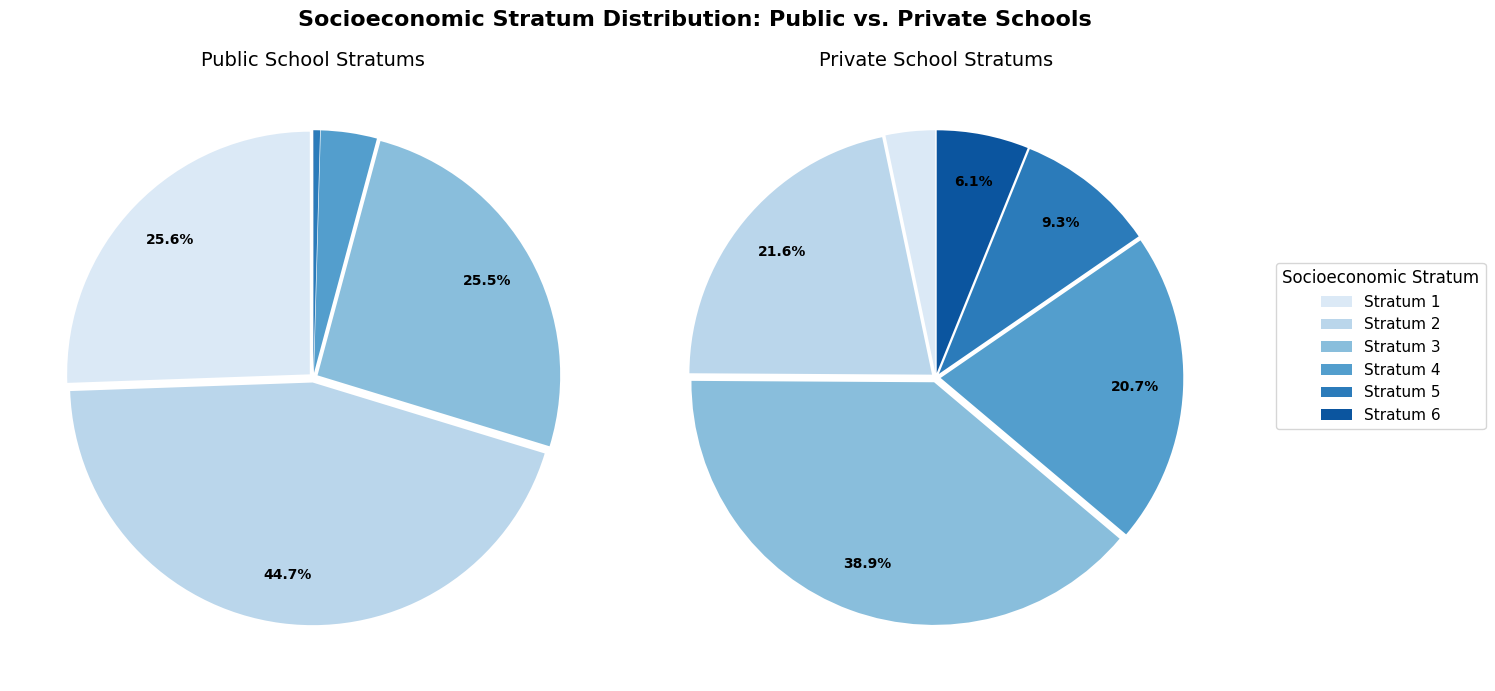

In [20]:
school_stratum = (
    d.groupby(["SCHOOL_NAT", "Stratum"])
      .size()
      .reset_index(name="count")
)

public_data = school_stratum[school_stratum["SCHOOL_NAT"] == "PUBLIC"]
private_data = school_stratum[school_stratum["SCHOOL_NAT"] == "PRIVATE"]

unique_strata = sorted(df["Stratum"].dropna().unique())
palette = sns.color_palette("Blues", n_colors=len(unique_strata))
color_map = {s: palette[i] for i, s in enumerate(unique_strata)}
label_map = {s: f"Stratum {int(s)}" for s in unique_strata}

# label overlapping fix
def autopct_generator(threshold):
    def inner_autopct(pct):
        return f"{pct:.1f}%" if pct > threshold else ""
    return inner_autopct


fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.suptitle('Socioeconomic Stratum Distribution: Public vs. Private Schools', fontsize=16, fontweight='bold')

pie_props_public = {
    "startangle": 90,
    "autopct": autopct_generator(4),
    "pctdistance": 0.8,
    "explode": [0.02] * len(public_data)
}

pie_props_private = {
    "startangle": 90,
    "autopct": autopct_generator(4),
    "pctdistance": 0.8,
    "explode": [0.02] * len(private_data)
}

#public
wedges1, _, autotexts1 = axes[0].pie(
    public_data["count"],
    colors=[color_map.get(s) for s in public_data["Stratum"]],
    **pie_props_public
)
axes[0].set_title("Public School Stratums", fontsize=14)
plt.setp(autotexts1, size=10, weight="bold", color="black")


#private
wedges2, _, autotexts2 = axes[1].pie(
    private_data["count"],
    colors=[color_map.get(s) for s in private_data["Stratum"]],
    **pie_props_private
)
axes[1].set_title("Private School Stratums", fontsize=14)
plt.setp(autotexts2, size=10, weight="bold", color="black")


legend_handles = [Patch(facecolor=color_map[s], label=label_map[s]) for s in unique_strata]
fig.legend(
    handles=legend_handles,
    title="Socioeconomic Stratum",
    loc="center left",
    bbox_to_anchor=(0.91, 0.5),
    fontsize=11,
    title_fontsize=12
)

plt.tight_layout(rect=[0, 0, 0.9, 0.96])
plt.show()

